In [1]:
import math
import random
import time
from dataclasses import dataclass
from typing import Any, Callable, Dict, List, Tuple
import json

import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Polygon
from shapely.validation import make_valid
from pprint import pprint

In [2]:
Point = Tuple[float, float]
Params = Dict[str, Any]

### Optimization Config

In [3]:
@dataclass(frozen=True)
class LBFGSConfig:
    restarts: int = 4
    memory_size: int = 8
    fd_epsilon: float = 2.0e-3
    initial_step: float = 1.0
    min_step: float = 1.0e-3
    max_line_search_steps: int = 12
    armijo_c1: float = 1.0e-4
    grad_norm_floor: float = 1.0e-6
    stale_patience: int = 6
    noise_scale: float = 0.018
    smoothness_weight: float = 0.008
    parameter_weight: float = 0.003
    area_weight: float = 0.030
    invalid_weight: float = 0.120
    boundary_sample_count: int = 140
    init_rigid_sigma: Tuple[float, float, float, float, float] = (0.28, 0.22, 0.18, 0.30, 0.30)
    init_offset_sigma_top: Tuple[float, float] = (0.060, 0.100)
    init_offset_sigma_left: Tuple[float, float] = (0.100, 0.080)


DEFAULT_LBFGS_CONFIG = LBFGSConfig()

### Targets

In [4]:
TARGET_PRIORS: Dict[str, Dict[str, Any]] = {
    "default": {
        "knot_count": 5,
        "initial_params": {},
        "manhattan": False,
    },
    "fish": {
        "knot_count": 5,
        "initial_params": {},
        "manhattan": False,
    },
    "L_shape": {
        "knot_count": 5,
        "initial_params": {},
        "manhattan": True,
    },
    "square": {
        "knot_count": 5,
        "initial_params": {},
        "manhattan": True,
    },
}


TARGET_SHAPES = {
    "square": Polygon([(0, 0), (1, 0), (1, 1), (0, 1)]),
    "L_shape": Polygon([(0, 0), (1, 0), (1, 0.5), (0.5, 0.5), (0.5, 1), (0, 1)]),
    "fish": Polygon(
        [
            (1.0, 0.5),
            (0.75, 0.0),
            (0.4, 0.0),
            (0.2, 0.4),
            (0.1, 0.4),
            (0.0, 0.0),
            (0.0, 1.0),
            (0.1, 0.6),
            (0.2, 0.6),
            (0.4, 1.0),
            (0.75, 1.0),
        ]
    ),
}

### Utils

In [5]:
def _as_valid_polygon(poly_pts: List[Point]) -> Polygon | None:
    if not poly_pts or len(poly_pts) < 3:
        return None
    try:
        poly = Polygon(poly_pts)
        if not poly.is_valid:
            poly = make_valid(poly)
        return poly
    except Exception:
        return None


def get_score(poly_pts: List[Point], target_shape_name: str) -> float:
    cand_poly = _as_valid_polygon(poly_pts)
    if cand_poly is None:
        return -10000.0
    try:
        target_poly = TARGET_SHAPES[target_shape_name]
        intersection = cand_poly.intersection(target_poly).area
        union = cand_poly.union(target_poly).area
        if union == 0 or intersection == 0:
            return -10000.0
        return intersection / union
    except Exception:
        return -10000.0


def polygon_iou(poly_a_pts: List[Point], poly_b_pts: List[Point]) -> float:
    poly_a = _as_valid_polygon(poly_a_pts)
    poly_b = _as_valid_polygon(poly_b_pts)
    if poly_a is None or poly_b is None:
        return 0.0
    try:
        intersection = poly_a.intersection(poly_b).area
        union = poly_a.union(poly_b).area
        if union == 0:
            return 0.0
        return intersection / union
    except Exception:
        return 0.0


def polygon_parts(geom: Any) -> List[Polygon]:
    if geom is None:
        return []
    if geom.geom_type == "Polygon":
        return [geom]
    if hasattr(geom, "geoms"):
        parts: List[Polygon] = []
        for sub_geom in geom.geoms:
            parts.extend(polygon_parts(sub_geom))
        return parts
    return []


def _catmull_rom_point(p0: Point, p1: Point, p2: Point, p3: Point, t: float) -> Point:
    t2 = t * t
    t3 = t2 * t
    x = 0.5 * (
        2.0 * p1[0]
        + (-p0[0] + p2[0]) * t
        + (2.0 * p0[0] - 5.0 * p1[0] + 4.0 * p2[0] - p3[0]) * t2
        + (-p0[0] + 3.0 * p1[0] - 3.0 * p2[0] + p3[0]) * t3
    )
    y = 0.5 * (
        2.0 * p1[1]
        + (-p0[1] + p2[1]) * t
        + (2.0 * p0[1] - 5.0 * p1[1] + 4.0 * p2[1] - p3[1]) * t2
        + (-p0[1] + 3.0 * p1[1] - 3.0 * p2[1] + p3[1]) * t3
    )
    return (x, y)


def sample_catmull_rom(points: List[Point], samples_per_segment: int) -> List[Point]:
    if len(points) < 2:
        return points[:]
    ext = [points[0]] + points + [points[-1]]
    sampled: List[Point] = []
    for seg_idx in range(len(points) - 1):
        p0, p1, p2, p3 = ext[seg_idx], ext[seg_idx + 1], ext[seg_idx + 2], ext[seg_idx + 3]
        start_step = 0 if seg_idx == 0 else 1
        for step in range(start_step, samples_per_segment + 1):
            t = step / float(samples_per_segment)
            sampled.append(_catmull_rom_point(p0, p1, p2, p3, t))
    return sampled


def _clone_params(params: Params) -> Params:
    return {k: (v[:] if isinstance(v, list) else v) for k, v in params.items()}


def _build_top_knots(params: Params) -> List[Point]:
    height = float(params["height"])
    offsets = params["t_offsets"]
    knots = [(0.0, height)]
    count = len(offsets)
    for idx, (ox, oy) in enumerate(offsets):
        t = (idx + 1) / float(count + 1)
        knots.append((t + ox, height + oy))
    knots.append((1.0, height))
    return knots


def _build_left_knots(params: Params) -> List[Point]:
    height = float(params["height"])
    slant = float(params["slant"])
    offsets = params["l_offsets"]
    knots = [(slant, 0.0)]
    count = len(offsets)
    for idx, (ox, oy) in enumerate(offsets):
        t = (idx + 1) / float(count + 1)
        knots.append((slant * (1.0 - t) + ox, t * height + oy))
    knots.append((0.0, height))
    return knots


def spline_polygon(params: Params) -> List[Point]:
    samples_per_segment = int(params.get("samples_per_segment", 12))
    height = float(params["height"])
    slant = float(params.get("slant", 0.0))
    scale = float(params["scale"])
    tx = float(params["translate_x"])
    ty = float(params["translate_y"])
    top_pts = sample_catmull_rom(_build_top_knots(params), samples_per_segment)
    left_pts = sample_catmull_rom(_build_left_knots(params), samples_per_segment)
    right_pts = [(x + 1.0, y) for x, y in left_pts]
    bottom_left = [(slant + 0.5 * x, 0.5 * (y - height)) for x, y in top_pts]
    bottom_right = [(slant + 0.5 + 0.5 * x, 0.5 * (y - height)) for x, y in top_pts]
    boundary = bottom_left[:-1] + bottom_right[:-1] + right_pts[:-1] + top_pts[::-1][:-1] + left_pts[::-1][:-1]
    return [(x * scale + tx, y * scale + ty) for x, y in boundary]


def reconstruct_polygon(params: Params) -> List[Point]:
    try:
        return spline_polygon(params)
    except Exception:
        return []


def _clamp_pair(value: Tuple[float, float], x_abs: float, y_abs: float) -> Tuple[float, float]:
    return (max(-x_abs, min(x_abs, value[0])), max(-y_abs, min(y_abs, value[1])))


def _project_strictly_increasing(values: List[float], lower: float, upper: float, min_gap: float) -> List[float]:
    if not values:
        return []
    projected = sorted(max(lower, min(upper, value)) for value in values)
    if len(projected) == 1:
        return projected
    feasible_gap = max(0.0, min(min_gap, (upper - lower) / float(len(projected))))
    projected[0] = max(lower, projected[0])
    for idx in range(1, len(projected)):
        projected[idx] = max(projected[idx], projected[idx - 1] + feasible_gap)
    if projected[-1] > upper:
        projected[-1] = upper
        for idx in range(len(projected) - 2, -1, -1):
            projected[idx] = min(projected[idx], projected[idx + 1] - feasible_gap)
    if projected[0] < lower:
        projected[0] = lower
        for idx in range(1, len(projected)):
            projected[idx] = max(projected[idx], projected[idx - 1] + feasible_gap)
    return [max(lower, min(upper, value)) for value in projected]


def _project_top_progression(params: Params) -> None:
    offsets = params["t_offsets"]
    count = len(offsets)
    if count == 0:
        return
    x_values = []
    for idx, (ox, _oy) in enumerate(offsets):
        t = (idx + 1) / float(count + 1)
        x_values.append(t + ox)
    x_values = _project_strictly_increasing(x_values, lower=0.02, upper=0.98, min_gap=0.03)
    for idx, (_ox, oy) in enumerate(offsets):
        t = (idx + 1) / float(count + 1)
        offsets[idx] = (x_values[idx] - t, oy)


def _project_left_progression(params: Params) -> None:
    offsets = params["l_offsets"]
    count = len(offsets)
    if count == 0:
        return
    height = float(params["height"])
    y_values = []
    for idx, (_ox, oy) in enumerate(offsets):
        t = (idx + 1) / float(count + 1)
        y_values.append(t * height + oy)
    y_values = _project_strictly_increasing(
        y_values,
        lower=0.02 * height,
        upper=0.98 * height,
        min_gap=0.03 * max(height, 1e-6),
    )
    for idx, (ox, _oy) in enumerate(offsets):
        t = (idx + 1) / float(count + 1)
        offsets[idx] = (ox, y_values[idx] - t * height)


def clamp_spline_params(params: Params) -> None:
    params["height"] = max(0.05, min(4.0, float(params["height"])))
    params["slant"] = max(-2.0, min(2.0, float(params["slant"])))
    params["scale"] = max(0.05, min(20.0, float(params["scale"])))
    params["translate_x"] = max(-12.0, min(12.0, float(params["translate_x"])))
    params["translate_y"] = max(-12.0, min(12.0, float(params["translate_y"])))
    params["t_offsets"] = [_clamp_pair(pair, 0.28, 0.55) for pair in params["t_offsets"]]
    params["l_offsets"] = [_clamp_pair(pair, 0.55, 0.45) for pair in params["l_offsets"]]
    _project_top_progression(params)
    _project_left_progression(params)


def _target_knot_count(target_shape_name: str) -> int:
    return int(TARGET_PRIORS.get(target_shape_name, TARGET_PRIORS["default"])["knot_count"])


def _default_spline_params(target_shape_name: str) -> Params:
    knot_count = _target_knot_count(target_shape_name)
    params: Params = {
        "height": 1.0,
        "slant": 0.0,
        "t_offsets": [(0.0, 0.0)] * knot_count,
        "l_offsets": [(0.0, 0.0)] * knot_count,
        "scale": 1.0,
        "translate_x": 0.0,
        "translate_y": 0.0,
        "samples_per_segment": 12,
    }
    params.update(TARGET_PRIORS.get(target_shape_name, TARGET_PRIORS["default"])["initial_params"])
    clamp_spline_params(params)
    return params


def _randomized_initial_params(target_shape_name: str, config: LBFGSConfig) -> Params:
    params = _default_spline_params(target_shape_name)
    h_sigma, sl_sigma, sc_sigma, tx_sigma, ty_sigma = config.init_rigid_sigma
    params["height"] += random.gauss(0.0, h_sigma)
    params["slant"] += random.gauss(0.0, sl_sigma)
    params["scale"] *= math.exp(random.gauss(0.0, sc_sigma))
    params["translate_x"] += random.gauss(0.0, tx_sigma)
    params["translate_y"] += random.gauss(0.0, ty_sigma)
    for idx, (ox, oy) in enumerate(params["t_offsets"]):
        params["t_offsets"][idx] = (
            ox + random.gauss(0.0, config.init_offset_sigma_top[0]),
            oy + random.gauss(0.0, config.init_offset_sigma_top[1]),
        )
    for idx, (ox, oy) in enumerate(params["l_offsets"]):
        params["l_offsets"][idx] = (
            ox + random.gauss(0.0, config.init_offset_sigma_left[0]),
            oy + random.gauss(0.0, config.init_offset_sigma_left[1]),
        )
    clamp_spline_params(params)
    return params


def _vectorize(params: Params) -> np.ndarray:
    values: List[float] = [
        float(params["height"]),
        float(params["slant"]),
        float(params["scale"]),
        float(params["translate_x"]),
        float(params["translate_y"]),
    ]
    for key in ("t_offsets", "l_offsets"):
        for ox, oy in params[key]:
            values.extend([float(ox), float(oy)])
    return np.asarray(values, dtype=np.float64)


def _devectorize(vector: np.ndarray, template: Params) -> Params:
    out = _clone_params(template)
    idx = 0
    out["height"] = float(vector[idx]); idx += 1
    out["slant"] = float(vector[idx]); idx += 1
    out["scale"] = float(vector[idx]); idx += 1
    out["translate_x"] = float(vector[idx]); idx += 1
    out["translate_y"] = float(vector[idx]); idx += 1
    for key in ("t_offsets", "l_offsets"):
        values = []
        for _ in out[key]:
            values.append((float(vector[idx]), float(vector[idx + 1])))
            idx += 2
        out[key] = values
    return out


def _sample_closed_polyline(poly_pts: List[Point], sample_count: int) -> np.ndarray:
    if not poly_pts:
        return np.zeros((0, 2), dtype=np.float64)
    pts = np.asarray(poly_pts, dtype=np.float64)
    if len(pts) < 2:
        return np.repeat(pts, sample_count, axis=0)
    nxt = np.vstack([pts[1:], pts[:1]])
    seg = nxt - pts
    seg_len = np.linalg.norm(seg, axis=1)
    total = float(seg_len.sum())
    if total <= 1e-12:
        return np.repeat(pts[:1], sample_count, axis=0)
    cumulative = np.concatenate([[0.0], np.cumsum(seg_len)])
    distances = np.linspace(0.0, total, sample_count, endpoint=False)
    sampled = np.zeros((sample_count, 2), dtype=np.float64)
    for idx, dist in enumerate(distances):
        seg_idx = int(np.searchsorted(cumulative, dist, side="right") - 1)
        seg_idx = min(max(seg_idx, 0), len(seg_len) - 1)
        seg_start = cumulative[seg_idx]
        local = 0.0 if seg_len[seg_idx] <= 1e-12 else (dist - seg_start) / seg_len[seg_idx]
        sampled[idx] = pts[seg_idx] * (1.0 - local) + nxt[seg_idx] * local
    return sampled


def _second_difference_penalty(array: np.ndarray) -> float:
    if len(array) < 3:
        return 0.0
    second = array[:-2] - 2.0 * array[1:-1] + array[2:]
    return float(np.mean(second * second))


def _offset_penalty(offsets: List[Point]) -> float:
    arr = np.asarray(offsets, dtype=np.float64)
    if len(arr) == 0:
        return 0.0
    magnitude = float(np.mean(arr * arr))
    smooth = _second_difference_penalty(arr)
    return magnitude + 2.0 * smooth


def _spline_parameter_penalty(params: Params) -> float:
    return 0.7 * (_offset_penalty(params["t_offsets"]) + _offset_penalty(params["l_offsets"]))


def _shoelace_area_centroid(poly_pts: List[Point]) -> Tuple[float, np.ndarray]:
    if len(poly_pts) < 3:
        return 0.0, np.zeros(2, dtype=np.float64)
    pts = np.asarray(poly_pts, dtype=np.float64)
    nxt = np.vstack([pts[1:], pts[:1]])
    cross = pts[:, 0] * nxt[:, 1] - nxt[:, 0] * pts[:, 1]
    area2 = float(np.sum(cross))
    area = 0.5 * area2
    if abs(area) <= 1e-12:
        return 0.0, np.mean(pts, axis=0)
    cx = float(np.sum((pts[:, 0] + nxt[:, 0]) * cross) / (6.0 * area))
    cy = float(np.sum((pts[:, 1] + nxt[:, 1]) * cross) / (6.0 * area))
    return abs(area), np.asarray([cx, cy], dtype=np.float64)


def _poly_area_centroid(poly_pts: List[Point]) -> Tuple[float, np.ndarray, bool]:
    poly = _as_valid_polygon(poly_pts)
    if poly is None:
        area, centroid = _shoelace_area_centroid(poly_pts)
        return area, centroid, False
    return float(poly.area), np.asarray([poly.centroid.x, poly.centroid.y], dtype=np.float64), True


@dataclass(frozen=True)
class TargetContext:
    target_name: str
    area: float


@dataclass(frozen=True)
class EnergyReport:
    total: float
    primary: float
    smoothness: float
    parameter: float
    area: float
    invalid: float


def prepare_target(target_name: str) -> TargetContext:
    poly = TARGET_SHAPES[target_name]
    return TargetContext(target_name=target_name, area=float(poly.area))


def evaluate_iou_energy(params: Params, target: TargetContext, config: LBFGSConfig) -> EnergyReport:
    poly_pts = spline_polygon(params)
    sampled = _sample_closed_polyline(poly_pts, config.boundary_sample_count)
    primary = 1.0 - max(0.0, get_score(poly_pts, target.target_name))
    smoothness = _second_difference_penalty(sampled)
    parameter = _spline_parameter_penalty(params)
    area, _centroid, is_valid = _poly_area_centroid(poly_pts)
    area_loss = ((area - target.area) / max(target.area, 1e-6)) ** 2
    invalid = 0.0 if is_valid else 1.0
    total = (
        primary
        + config.smoothness_weight * smoothness
        + config.parameter_weight * parameter
        + config.area_weight * area_loss
        + config.invalid_weight * invalid
    )
    return EnergyReport(
        total=float(total),
        primary=float(primary),
        smoothness=float(smoothness),
        parameter=float(parameter),
        area=float(area_loss),
        invalid=float(invalid),
    )


def _estimate_gradient(vector: np.ndarray, template: Params, target: TargetContext, config: LBFGSConfig) -> np.ndarray:
    grad = np.zeros_like(vector)
    for idx in range(len(vector)):
        eps = config.fd_epsilon * max(1.0, abs(vector[idx]))
        if eps <= 1e-8:
            eps = config.fd_epsilon
        plus_vec = vector.copy()
        minus_vec = vector.copy()
        plus_vec[idx] += eps
        minus_vec[idx] -= eps
        plus_params = _devectorize(plus_vec, template)
        minus_params = _devectorize(minus_vec, template)
        clamp_spline_params(plus_params)
        clamp_spline_params(minus_params)
        plus_energy = evaluate_iou_energy(plus_params, target, config).total
        minus_energy = evaluate_iou_energy(minus_params, target, config).total
        grad[idx] = (plus_energy - minus_energy) / (2.0 * eps)
    return grad


def _two_loop_direction(grad: np.ndarray, s_history: List[np.ndarray], y_history: List[np.ndarray]) -> np.ndarray:
    if not s_history:
        return -grad.copy()
    q = grad.copy()
    alphas: List[float] = []
    rhos: List[float] = []
    for s_vec, y_vec in zip(reversed(s_history), reversed(y_history)):
        ys = float(np.dot(y_vec, s_vec))
        if ys <= 1e-12:
            alphas.append(0.0)
            rhos.append(0.0)
            continue
        rho = 1.0 / ys
        alpha = rho * float(np.dot(s_vec, q))
        q -= alpha * y_vec
        alphas.append(alpha)
        rhos.append(rho)
    last_s = s_history[-1]
    last_y = y_history[-1]
    yy = float(np.dot(last_y, last_y))
    gamma = float(np.dot(last_s, last_y) / yy) if yy > 1e-12 else 1.0
    r = gamma * q
    for idx, (s_vec, y_vec) in enumerate(zip(s_history, y_history)):
        rho = rhos[-(idx + 1)]
        alpha = alphas[-(idx + 1)]
        if rho == 0.0:
            continue
        beta = rho * float(np.dot(y_vec, r))
        r += s_vec * (alpha - beta)
    return -r


def _line_search(
    current_vec: np.ndarray,
    current: Params,
    current_energy: float,
    grad: np.ndarray,
    direction: np.ndarray,
    target: TargetContext,
    config: LBFGSConfig,
    end_time: float,
) -> Tuple[np.ndarray | None, Params | None, EnergyReport | None]:
    directional_derivative = float(np.dot(grad, direction))
    if directional_derivative >= 0.0:
        direction = -grad
        directional_derivative = float(np.dot(grad, direction))
    if directional_derivative >= 0.0:
        return None, None, None
    step = config.initial_step
    for _ in range(config.max_line_search_steps):
        if time.time() >= end_time:
            break
        proposal_vec = current_vec + step * direction
        proposal = _devectorize(proposal_vec, current)
        clamp_spline_params(proposal)
        proposal_vec = _vectorize(proposal)
        proposal_report = evaluate_iou_energy(proposal, target, config)
        if proposal_report.total <= current_energy + config.armijo_c1 * step * directional_derivative:
            return proposal_vec, proposal, proposal_report
        step *= 0.5
        if step < config.min_step:
            break
    return None, None, None


def summarize_lbfgs_params(params: Params, target_shape_name: str, elapsed_seconds: float, energy_report: EnergyReport, best_eval_seen: float) -> Dict[str, Any]:
    internal_poly = spline_polygon(params)
    reconstructed_poly = reconstruct_polygon(params)
    eval_score = get_score(reconstructed_poly, target_shape_name)
    return {
        "elapsed_seconds": elapsed_seconds,
        "energy_total": energy_report.total,
        "energy_primary": energy_report.primary,
        "energy_smoothness": energy_report.smoothness,
        "energy_parameter": energy_report.parameter,
        "energy_area": energy_report.area,
        "energy_invalid": energy_report.invalid,
        "internal_score": -energy_report.total,
        "eval_score": eval_score,
        "best_eval_seen": best_eval_seen,
        "consistency_iou": polygon_iou(internal_poly, reconstructed_poly),
    }


def _optimize_single_restart(
    target_name: str,
    initial_params: Params,
    time_budget: float,
    started_at: float,
    config: LBFGSConfig,
    progress_callback: Callable[[Dict[str, Any]], None] | None,
    restart_index: int,
) -> Tuple[Params, EnergyReport, List[Dict[str, Any]]]:
    end_time = time.time() + time_budget
    trace: List[Dict[str, Any]] = []
    target = prepare_target(target_name)

    current = _clone_params(initial_params)
    clamp_spline_params(current)
    current_vec = _vectorize(current)
    current_report = evaluate_iou_energy(current, target, config)
    current_eval = get_score(reconstruct_polygon(current), target_name)

    best_eval_params = _clone_params(current)
    best_eval_seen = current_eval
    s_history: List[np.ndarray] = []
    y_history: List[np.ndarray] = []
    stale_steps = 0

    def record(params: Params, report: EnergyReport, phase: str) -> None:
        entry = summarize_lbfgs_params(
            params=params,
            target_shape_name=target_name,
            elapsed_seconds=time.time() - started_at,
            energy_report=report,
            best_eval_seen=best_eval_seen,
        )
        entry["phase"] = phase
        entry["restart"] = restart_index
        trace.append(entry)
        if progress_callback is not None:
            progress_callback(entry)

    record(current, current_report, "restart_start")

    while time.time() < end_time:
        grad = _estimate_gradient(current_vec, current, target, config)
        if not np.any(np.isfinite(grad)):
            break
        grad_norm = float(np.linalg.norm(grad))
        if grad_norm < config.grad_norm_floor:
            stale_steps += 1
        direction = _two_loop_direction(grad, s_history, y_history)
        proposal_vec, proposal, proposal_report = _line_search(
            current_vec=current_vec,
            current=current,
            current_energy=current_report.total,
            grad=grad,
            direction=direction,
            target=target,
            config=config,
            end_time=end_time,
        )
        if proposal is None or proposal_report is None or proposal_vec is None:
            stale_steps += 1
        else:
            new_grad = _estimate_gradient(proposal_vec, proposal, target, config)
            s_vec = proposal_vec - current_vec
            y_vec = new_grad - grad
            ys = float(np.dot(y_vec, s_vec))
            if ys > 1e-10:
                s_history.append(s_vec)
                y_history.append(y_vec)
                if len(s_history) > config.memory_size:
                    s_history.pop(0)
                    y_history.pop(0)
            current = proposal
            current_vec = proposal_vec
            current_report = proposal_report
            stale_steps = 0
            current_eval = get_score(reconstruct_polygon(current), target_name)
            if current_eval > best_eval_seen + 1e-12:
                best_eval_seen = current_eval
                best_eval_params = _clone_params(current)
                record(current, current_report, "eval_improve")
        if stale_steps >= config.stale_patience:
            noisy = _clone_params(best_eval_params)
            for key in ("t_offsets", "l_offsets"):
                noisy[key] = [
                    (
                        ox + random.gauss(0.0, config.noise_scale),
                        oy + random.gauss(0.0, config.noise_scale),
                    )
                    for ox, oy in noisy[key]
                ]
            noisy["height"] += random.gauss(0.0, 0.08)
            noisy["slant"] += random.gauss(0.0, 0.06)
            noisy["scale"] *= math.exp(random.gauss(0.0, 0.04))
            noisy["translate_x"] += random.gauss(0.0, 0.08)
            noisy["translate_y"] += random.gauss(0.0, 0.08)
            clamp_spline_params(noisy)
            current = noisy
            current_vec = _vectorize(noisy)
            current_report = evaluate_iou_energy(current, target, config)
            s_history.clear()
            y_history.clear()
            stale_steps = 0

    final_report = evaluate_iou_energy(best_eval_params, target, config)
    record(best_eval_params, final_report, "restart_end")
    return best_eval_params, final_report, trace


def find_escher_tile_spline_lbfgs(
    target_shape_name: str,
    time_limit_seconds: float,
    starting_data: Dict[str, Any] | None = None,
    progress_callback: Callable[[Dict[str, Any]], None] | None = None,
    config: LBFGSConfig = DEFAULT_LBFGS_CONFIG,
) -> Dict[str, Any]:
    started_at = time.time()
    best_params: Params | None = None
    best_eval_score = -1e18
    if starting_data:
        warm = _default_spline_params(target_shape_name)
        for key, value in starting_data.items():
            if key in warm and not isinstance(value, list):
                warm[key] = value
        clamp_spline_params(warm)
        best_params = warm
        best_eval_score = get_score(reconstruct_polygon(warm), target_shape_name)
    restarts = max(1, config.restarts)
    for restart_idx in range(restarts):
        elapsed = time.time() - started_at
        remaining = time_limit_seconds - elapsed
        remaining_restarts = restarts - restart_idx
        if remaining <= 0:
            break
        restart_budget = remaining / remaining_restarts
        initial_params = _default_spline_params(target_shape_name) if restart_idx == 0 else _randomized_initial_params(target_shape_name, config)
        params, _report, _trace = _optimize_single_restart(
            target_name=target_shape_name,
            initial_params=initial_params,
            time_budget=restart_budget,
            started_at=started_at,
            config=config,
            progress_callback=progress_callback,
            restart_index=restart_idx,
        )
        eval_score = get_score(reconstruct_polygon(params), target_shape_name)
        if best_params is None or eval_score > best_eval_score + 1e-12:
            best_params = params
            best_eval_score = eval_score
    if best_params is None:
        best_params = _default_spline_params(target_shape_name)
    return best_params


def visualize_shapes(polys: Dict[str, List[Point]], scores: Dict[str, float], title: str):
    targets = list(TARGET_SHAPES.keys())
    fig, axes = plt.subplots(1, len(targets), figsize=(4 * len(targets), 4))
    if len(targets) == 1:
        axes = [axes]
    for ax, target_name in zip(axes, targets):
        target_poly = TARGET_SHAPES[target_name]
        x, y = target_poly.exterior.xy
        ax.plot(x, y, color="#1d4ed8", label="Target", linewidth=2)
        cand_poly = _as_valid_polygon(polys.get(target_name, []))
        if cand_poly is not None:
            for idx, part in enumerate(polygon_parts(cand_poly)):
                cx, cy = part.exterior.xy
                ax.fill(cx, cy, alpha=0.5, color="#f59e0b", label="Candidate" if idx == 0 else None)
                ax.plot(cx, cy, color="#dc2626", linewidth=1)
        ax.set_title(f"{target_name}\nIoU: {scores.get(target_name, -1e4):.4f}")
        ax.legend()
        ax.set_aspect("equal")
    fig.suptitle(title)
    fig.tight_layout()
    return fig


def _affine_poly(poly_pts: List[Point], sx: float = 1.0, sy: float = 1.0, tx: float = 0.0, ty: float = 0.0) -> List[Point]:
    return [(sx * x + tx, sy * y + ty) for x, y in poly_pts]


def _mirror_poly_x(poly_pts: List[Point], center_x: float) -> List[Point]:
    return [(2.0 * center_x - x, y) for x, y in poly_pts]


def _plot_poly(ax, poly_pts: List[Point], *, facecolor: str, edgecolor: str, label: str, alpha: float = 0.5, linewidth: float = 1.5):
    poly = _as_valid_polygon(poly_pts)
    if poly is None:
        return
    for idx, part in enumerate(polygon_parts(poly)):
        x, y = part.exterior.xy
        ax.fill(x, y, color=facecolor, alpha=alpha, label=label if idx == 0 else None)
        ax.plot(x, y, color=edgecolor, linewidth=linewidth)


def visualize_learned_family(params: Params, title: str = "Learned Tile Family"):
    canonical = _clone_params(params)
    canonical["scale"] = 1.0
    canonical["translate_x"] = 0.0
    canonical["translate_y"] = 0.0
    tile = spline_polygon(canonical)
    height = float(canonical["height"])
    slant = float(canonical.get("slant", 0.0))
    sibling = _affine_poly(tile, tx=1.0)

    def _translated_scaled_child(poly_pts: List[Point], anchor_x: float) -> List[Point]:
        scaled = _affine_poly(poly_pts, sx=0.5, sy=0.5)
        return _affine_poly(scaled, tx=anchor_x, ty=-0.5 * height)

    tile_bottom_left = slant
    tile_bottom_mid = slant + 0.5
    sibling_bottom_left = slant + 1.0
    sibling_bottom_mid = slant + 1.5

    shapes = [
        ("tile", tile, "#93c5fd", "#1d4ed8", 0.45, 2.0),
        ("sibling = tile + (1, 0)", sibling, "#fcd34d", "#b45309", 0.45, 2.0),
        ("tile child 0", _translated_scaled_child(tile, tile_bottom_left), "#3b82f6", "#1e40af", 0.82, 1.6),
        ("tile child 1", _translated_scaled_child(tile, tile_bottom_mid), "#2563eb", "#1e3a8a", 0.82, 1.6),
        ("sibling child 0", _translated_scaled_child(tile, sibling_bottom_left), "#f59e0b", "#92400e", 0.82, 1.6),
        ("sibling child 1", _translated_scaled_child(tile, sibling_bottom_mid), "#d97706", "#78350f", 0.82, 1.6),
    ]

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    for name, poly_pts, facecolor, edgecolor, alpha, linewidth in shapes:
        _plot_poly(ax, poly_pts, facecolor=facecolor, edgecolor=edgecolor, label=name, alpha=alpha, linewidth=linewidth)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    ax.set_frame_on(False)
    fig.tight_layout()
    return fig


def plot_evolution(traces_by_target: Dict[str, List[Dict[str, Any]]]):
    targets = list(TARGET_SHAPES.keys())
    fig, axes = plt.subplots(1, len(targets), figsize=(5 * len(targets), 4), sharey=True)
    if len(targets) == 1:
        axes = [axes]
    for ax, target_name in zip(axes, targets):
        trace = traces_by_target[target_name]
        times = [entry["elapsed_seconds"] for entry in trace]
        scores = [max(0.0, min(1.0, entry.get("best_eval_seen", entry["eval_score"]))) for entry in trace]
        ax.step(times, scores, where="post", linewidth=2)
        ax.set_title(target_name)
        ax.set_xlabel("Elapsed seconds")
        ax.set_ylabel("Best IoU")
        ax.set_ylim(0.0, 1.05)
        ax.grid(alpha=0.3)
    fig.suptitle("Spline IoU L-BFGS")
    fig.tight_layout()
    return fig


def run_lbfgs_target(target_name: str, seconds: float = 5.0, seed: int = 0, config: LBFGSConfig = DEFAULT_LBFGS_CONFIG):
    random.seed(seed)
    trace: List[Dict[str, Any]] = []

    def on_progress(entry):
        trace.append(dict(entry))

    started = time.time()
    params = find_escher_tile_spline_lbfgs(
        target_shape_name=target_name,
        time_limit_seconds=seconds,
        starting_data=None,
        progress_callback=on_progress,
        config=config,
    )
    poly = reconstruct_polygon(params)
    final_report = evaluate_iou_energy(params, prepare_target(target_name), config)
    summary = summarize_lbfgs_params(params, target_name, time.time() - started, final_report, max([e['best_eval_seen'] for e in trace], default=0.0))
    if not trace or trace[-1]["eval_score"] < summary["eval_score"] - 1e-12:
        trace.append(summary)
    return {
        "target": target_name,
        "seed": seed,
        "seconds": seconds,
        "params": params,
        "poly": poly,
        "trace": trace,
        "summary": summary,
    }


def run_lbfgs_demo(seconds_per_target: float = 5.0, seed: int = 0, config: LBFGSConfig = DEFAULT_LBFGS_CONFIG):
    rows = []
    polys = {}
    scores = {}
    traces = {}
    params_by_target = {}
    started = time.time()
    for target_index, target_name in enumerate(TARGET_SHAPES.keys()):
        result = run_lbfgs_target(target_name, seconds=seconds_per_target, seed=seed + target_index, config=config)
        summary = result["summary"]
        rows.append((target_name, summary["eval_score"], summary["energy_total"], len(result["trace"])))
        polys[target_name] = result["poly"]
        scores[target_name] = summary["eval_score"]
        traces[target_name] = result["trace"]
        params_by_target[target_name] = result["params"]
    shapes_fig = visualize_shapes(polys, scores, "Spline IoU L-BFGS Final Shapes")
    evolution_fig = plot_evolution(traces)
    return {
        "rows": rows,
        "polys": polys,
        "scores": scores,
        "traces": traces,
        "params_by_target": params_by_target,
        "shapes_fig": shapes_fig,
        "evolution_fig": evolution_fig,
        "wall_clock_seconds": time.time() - started,
    }

def _fmt_glsl_float(value: float) -> str:
    value = 0.0 if abs(value) < 1.0e-9 else float(value)
    text = f"{value:.9f}".rstrip("0").rstrip(".")
    if text in {"", "-0", "-0.0"}:
        text = "0"
    if "." not in text:
        text += ".0"
    return text


def _catmull_rom_to_bezier_segments(points: List[Point]) -> List[Tuple[Point, Point, Point, Point]]:
    if len(points) < 2:
        return []
    ext = [points[0]] + points + [points[-1]]
    segments: List[Tuple[Point, Point, Point, Point]] = []
    for seg_idx in range(len(points) - 1):
        p0, p1, p2, p3 = ext[seg_idx], ext[seg_idx + 1], ext[seg_idx + 2], ext[seg_idx + 3]
        b0 = p1
        b1 = (p1[0] + (p2[0] - p0[0]) / 6.0, p1[1] + (p2[1] - p0[1]) / 6.0)
        b2 = (p2[0] - (p3[0] - p1[0]) / 6.0, p2[1] - (p3[1] - p1[1]) / 6.0)
        b3 = p2
        segments.append((b0, b1, b2, b3))
    return segments


def _reverse_cubic_segment(segment: Tuple[Point, Point, Point, Point]) -> Tuple[Point, Point, Point, Point]:
    p0, p1, p2, p3 = segment
    return (p3, p2, p1, p0)


def _affine_point(point: Point, *, sx: float = 1.0, sy: float = 1.0, tx: float = 0.0, ty: float = 0.0) -> Point:
    return (sx * point[0] + tx, sy * point[1] + ty)


def _affine_cubic_segment(
    segment: Tuple[Point, Point, Point, Point],
    *,
    sx: float = 1.0,
    sy: float = 1.0,
    tx: float = 0.0,
    ty: float = 0.0,
) -> Tuple[Point, Point, Point, Point]:
    return tuple(_affine_point(point, sx=sx, sy=sy, tx=tx, ty=ty) for point in segment)


def export_binary_tile_glsl_snippet(params: Params, symbol: str = "EXPORTED_TILE") -> str:
    if not symbol.isidentifier():
        raise ValueError(f"symbol must be a valid identifier, got {symbol!r}")

    canonical = _clone_params(params)
    canonical["scale"] = 1.0
    canonical["translate_x"] = 0.0
    canonical["translate_y"] = 0.0

    height = float(canonical["height"])
    slant = float(canonical.get("slant", 0.0))

    top_segments = _catmull_rom_to_bezier_segments(_build_top_knots(canonical))
    left_segments = _catmull_rom_to_bezier_segments(_build_left_knots(canonical))

    boundary_segments: List[Tuple[Point, Point, Point, Point]] = []
    boundary_segments.extend(_affine_cubic_segment(seg, sx=0.5, sy=0.5, tx=slant, ty=-0.5 * height) for seg in top_segments)
    boundary_segments.extend(_affine_cubic_segment(seg, sx=0.5, sy=0.5, tx=slant + 0.5, ty=-0.5 * height) for seg in top_segments)
    boundary_segments.extend(_affine_cubic_segment(seg, tx=1.0) for seg in left_segments)
    boundary_segments.extend(_reverse_cubic_segment(seg) for seg in reversed(top_segments))
    boundary_segments.extend(_reverse_cubic_segment(seg) for seg in reversed(left_segments))

    preview_poly = spline_polygon(canonical)
    all_points = preview_poly[:] + [point for seg in boundary_segments for point in seg]
    min_x = min(point[0] for point in all_points)
    min_y = min(point[1] for point in all_points)
    max_x = max(point[0] for point in all_points)
    max_y = max(point[1] for point in all_points)

    parts = [part for part in symbol.split("_") if part]
    curve_fn_name = "get" + "".join(part[:1].upper() + part[1:].lower() for part in parts) + "Curve"

    lines = [
        f"// Generated by export_binary_tile_shader_paste_block()",
        f"const int {symbol}_CURVE_COUNT = {len(boundary_segments)};",
        f"const float {symbol}_HEIGHT = {_fmt_glsl_float(height)};",
        f"const float {symbol}_SLANT = {_fmt_glsl_float(slant)};",
        f"const vec2 {symbol}_BOUNDS_MIN = vec2({_fmt_glsl_float(min_x)}, {_fmt_glsl_float(min_y)});",
        f"const vec2 {symbol}_BOUNDS_MAX = vec2({_fmt_glsl_float(max_x)}, {_fmt_glsl_float(max_y)});",
        f"void {curve_fn_name}(int i, out vec2 p0, out vec2 p1, out vec2 p2, out vec2 p3) {{",
    ]

    for idx, segment in enumerate(boundary_segments):
        assignments = []
        for point_name, point in zip(("p0", "p1", "p2", "p3"), segment):
            assignments.append(f"{point_name} = vec2({_fmt_glsl_float(point[0])}, {_fmt_glsl_float(point[1])});")
        lines.append(f"  if (i == {idx}) {{ {' '.join(assignments)} return; }}")

    lines.append("  p0 = vec2(0.0); p1 = vec2(0.0); p2 = vec2(0.0); p3 = vec2(0.0);")
    lines.append("}")
    return "\n".join(lines)


def export_binary_tile_shader_paste_block(
    params: Params,
    *,
    js_name: str = "EXPORTED_TILE_GLSL",
    symbol: str = "EXPORTED_TILE",
) -> str:
    if not js_name.isidentifier():
        raise ValueError(f"js_name must be a valid identifier, got {js_name!r}")
    glsl = export_binary_tile_glsl_snippet(params, symbol=symbol)
    return f"const {js_name} = String.raw`\n{glsl}\n`;"


def export_binary_tile_json(params: Params) -> str:
    canonical = _clone_params(params)
    canonical["scale"] = 1.0
    canonical["translate_x"] = 0.0
    canonical["translate_y"] = 0.0
    payload = {
        "height": float(canonical["height"]),
        "slant": float(canonical.get("slant", 0.0)),
        "top_knots": _build_top_knots(canonical),
        "left_knots": _build_left_knots(canonical),
        "boundary_poly": spline_polygon(canonical),
    }
    return json.dumps(payload, indent=2)

## Run the Solver

square    eval_iou=1.0000  energy=0.00000  updates=128
L_shape   eval_iou=0.8461  energy=0.15515  updates=179
fish      eval_iou=0.7976  energy=0.20261  updates=151
wall_clock_seconds=361.41


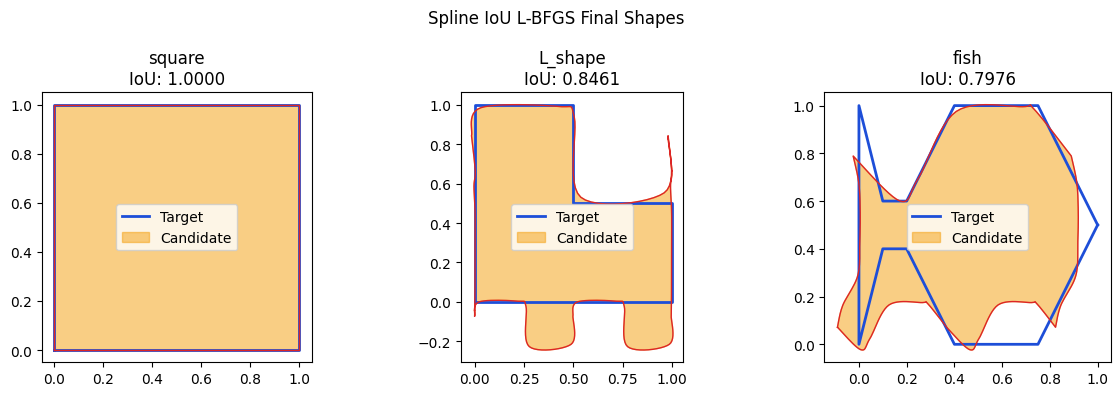

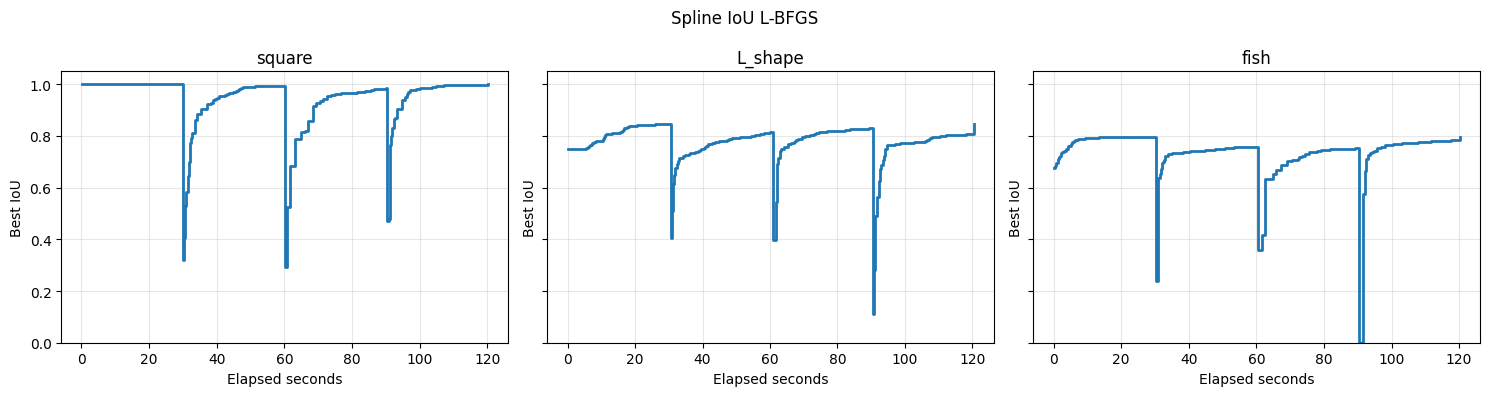

In [6]:
SECONDS_PER_TARGET = 120.0
SEED = 0

demo = run_lbfgs_demo(seconds_per_target=SECONDS_PER_TARGET, seed=SEED)

for target_name, eval_score, energy_total, updates in demo["rows"]:
    print(f"{target_name:8s}  eval_iou={eval_score:.4f}  energy={energy_total:.5f}  updates={updates}")
print(f"wall_clock_seconds={demo['wall_clock_seconds']:.2f}")

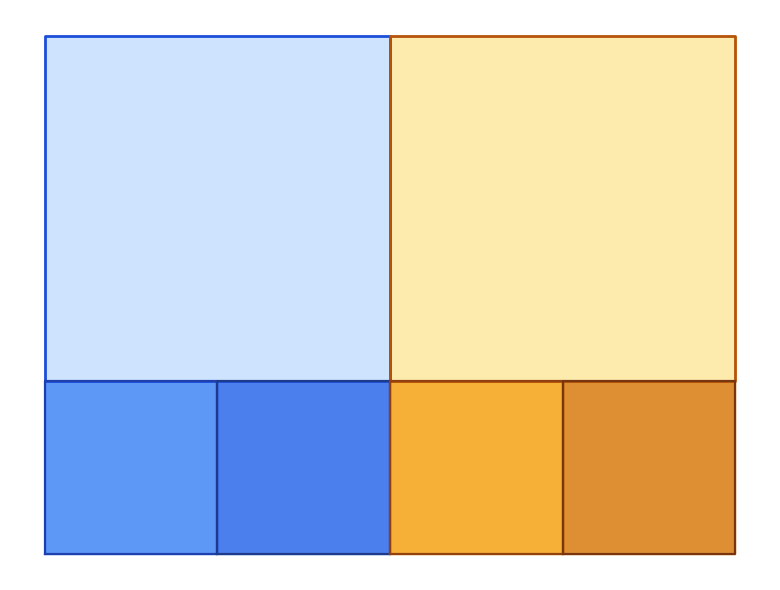

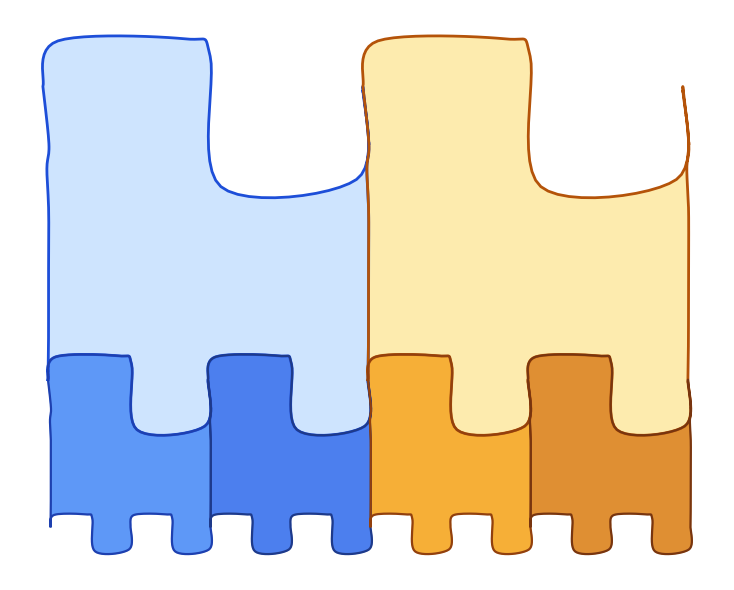

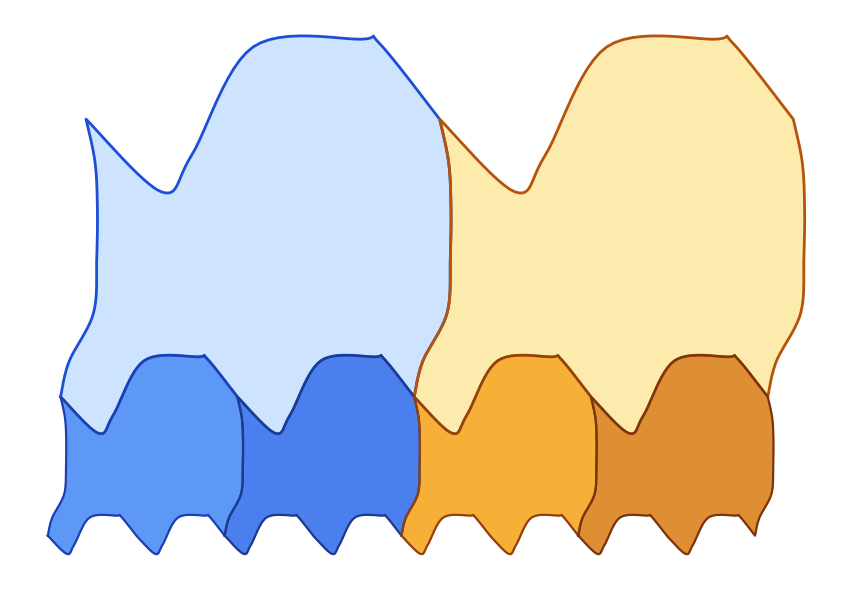

In [7]:
for target_name, params in demo["params_by_target"].items():
    visualize_learned_family(params, title=f"{target_name} learned family")

## Shader Payload

Replace `EXPORTED_TILE_GLSL` in `index-binary-escher-tiling.html` with the payload below.

In [8]:
export_target_name = "fish"
print(export_binary_tile_shader_paste_block(demo["params_by_target"][export_target_name]))

const EXPORTED_TILE_GLSL = String.raw`
// Generated by export_binary_tile_shader_paste_block()
const int EXPORTED_TILE_CURVE_COUNT = 30;
const float EXPORTED_TILE_HEIGHT = 0.78518857;
const float EXPORTED_TILE_SLANT = -0.072066209;
const vec2 EXPORTED_TILE_BOUNDS_MIN = vec2(-0.072066209, -0.111444048);
const vec2 EXPORTED_TILE_BOUNDS_MAX = vec2(1.034007778, 1.044549199);
void getExportedTileCurve(int i, out vec2 p0, out vec2 p1, out vec2 p2, out vec2 p3) {
  if (i == 0) { p0 = vec2(-0.072066209, 0.0); p1 = vec2(-0.054328439, -0.017132342); p2 = vec2(0.009564734, -0.094144056); p3 = vec2(0.03436041, -0.102794052); return; }
  if (i == 1) { p0 = vec2(0.03436041, -0.102794052); p1 = vec2(0.059156087, -0.111444048); p2 = vec2(0.055062153, -0.086063816); p3 = vec2(0.076707852, -0.051899975); return; }
  if (i == 2) { p0 = vec2(0.076707852, -0.051899975); p1 = vec2(0.098353552, -0.017736134); p2 = vec2(0.124221359, 0.074697674); p3 = vec2(0.164234607, 0.102188994); return; }
  if (i == 3) { 